# Solution Computational Foundation of Electrodynamics 4rd ed - Reitz, John .R

## CHAPTER 1.Vector Analysis 

In [100]:
import numpy as np
import scipy as sp
import sympy as smp
import matplotlib.pyplot as plt
from sympy.vector import CoordSys3D

plt.rcParams['text.usetex'] = True

plt.style.use('dark_background')

from colorama import Fore, Back

**Table of contents**<a id='toc0_'></a> 
- [Symbolic definition of a vector](#toc1_)
- [(Soft) magnitude of a vector](#toc2_)
- [Angle of vector components with respect to the coordinate axis](#toc3_)
- [Projection](#toc4_)
- [Directional derivative and gradient](#toc4_)
    - [Calculating the gradient of a vector field in 2 algebraic ways](#toc4_1_)

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_'></a>[Symbolic definition of a vector](#toc0_)

$ A \in \mathbb{R}^3 $

In [101]:
N = CoordSys3D('N')
Ax ,Ay ,Az = smp.symbols('A_x A_y A_z',real=True)
A_com = smp.Matrix([Ax,Ay,Az])
A = Ax*N.i + Ay*N.j + Az*N.k
display(A)

A_x*N.i + A_y*N.j + A_z*N.k

## <a id='toc2_'></a>[(Soft) magnitude of a vector](#toc0_)

$$ \Vert A \Vert_p = \left( \sum_i |A_i|^p \right)^{1/p} \quad \quad \mathbf{A} = (A_1,\cdots,A_n) \in \mathbb{R}^n $$

In [102]:
# Symbolic
print(f'norm(A) ?= magnitude(A): {Fore.GREEN}{A_com.norm() == A.magnitude()}')
display(A_com.norm())

test_list = [123,4,12,31,2,12,12]
x = np.asarray(test_list, dtype=np.float64)
# Numerical
def p_norm(x: np.ndarray, p: float):
    if np.isinf(p):
        return np.max(np.abs(x))
    elif p >= 1:
        return (np.sum(np.abs(x)**p))**(1/p)
    else:
        raise ValueError("p must be >= 1.0 or inf.")

# Automatic ((0,infinity) order)
print(f'use numpy (Automatic): {np.linalg.norm(test_list)}')

################################################################################
#  Numerical VS Automatic
print('How many difficult between Numerical and Automatic Ways?')

print("-" * 70)
print(f"{'p':>5} | {'p_norm (manual)':>20} | {'np.linalg.norm':>20} | {'diff':>15}")
print("-" * 70)
for p in [1, 2, 3, 5, 7, 10, 20, 50, np.inf]:
    manual = p_norm(x, p)
    numpy_val = np.linalg.norm(x, ord=p)
    print(f"{p!s:>5} | {manual:>20.15f} | {numpy_val:>20.15f} | {abs(manual-numpy_val):>15.2e}")

norm(A) ?= magnitude(A): True


sqrt(A_x**2 + A_y**2 + A_z**2)

use numpy (Automatic): 128.6157066613561
How many difficult between Numerical and Automatic Ways?
----------------------------------------------------------------------
    p |      p_norm (manual) |       np.linalg.norm |            diff
----------------------------------------------------------------------
    1 |  196.000000000000000 |  196.000000000000000 |        0.00e+00
    2 |  128.615706661356114 |  128.615706661356114 |        0.00e+00
    3 |  123.767383878995176 |  123.767383878995176 |        0.00e+00
    5 |  123.025658508621760 |  123.025658508621760 |        0.00e+00
    7 |  123.001139422728173 |  123.001139422728173 |        0.00e+00
   10 |  123.000012722402985 |  123.000012722402985 |        0.00e+00
   20 |  123.000000000006608 |  123.000000000006608 |        0.00e+00
   50 |  123.000000000000014 |  123.000000000000014 |        0.00e+00
  inf |  123.000000000000000 |  123.000000000000000 |        0.00e+00


### <a id='toc3_'></a>[Angle of vector components with respect to the coordinate axis](#toc0_)

<img src="Cosine.png" width="600" style="display: block; margin: 0 auto;">

$$ \cos{\alpha}^2 + \cos{\beta}^2 + \cos{\gamma}^2 = 1 $$
$$ \alpha = \arccos{(\frac{A_x}{A})} \quad ; \quad \beta = \arccos{(\frac{A_y}{A})} \quad ; \quad \gamma = \arccos{(\frac{A_z}{A})}$$

In [103]:
# direction cosines
def direco(Vec):
    Alpha, Gamma, Beta = [np.arccos(Vec[0]/np.linalg.norm(Vec)),
                        np.arccos(Vec[1]/np.linalg.norm(Vec)),
                        np.arccos(Vec[2]/np.linalg.norm(Vec))]
    # Proof
    print(f'Sum of the square of the direction cosine: {sum([np.cos(i)**2 for i in [Alpha,Gamma,Beta]])}')
    if sum([np.cos(i)**2 for i in [Alpha,Gamma,Beta]]) == 1.0: print('so Worked!')
    else: print('Something is not right!')
    return Alpha,Gamma,Beta
Vect = np.array([1,5,3])
direco(Vect)

Sum of the square of the direction cosine: 1.0
so Worked!


(np.float64(1.400950038711223),
 np.float64(0.5639426413606289),
 np.float64(1.038988229847329))

In [104]:
alpha = smp.acos(A_com[0]/A_com.norm())
beta = smp.acos(A_com[1]/A_com.norm())
gamma = smp.acos(A_com[2]/A_com.norm())

for i in [[alpha,0],[beta,1],[gamma,2]]:
    print(i[:][0] == smp.acos(A_com[i[:][1]]/A_com.norm()))

True
True
True


### <a id='toc4_'> </a>[Projection](#toc0_)

<div style="display: flex; justify-content: center; align-items: center; gap: 10px;">
  <img src="Proj.png" width="600">
  <img src="Proj_info.png" width="600">
</div>


$$ \text{proj}_v(u) = \frac{u \cdot v}{|v|^2} v \quad \quad \left\{ \begin{aligned} 
\operatorname{Proj}_{\mathbf{b}}\mathbf{R} &= \left(\frac{\| \vec{R} \times \vec{a} \|}{a} \right) \hat{b} \\ 
\operatorname{Proj}_{\mathbf{a}}\mathbf{R} &= \left(\frac{\vec{R} \cdot \vec{a}}{a} \right) \hat{a} 
\end{aligned} \right. $$


In [105]:
def Proj(u,v): return (u.dot(v) / np.linalg.norm(v)**2)*v
def hat(u): return u/np.linalg.norm(u)

a,b, R  = np.array([1,0,0]) , np.array([0,1,0]) , np.array([3,2,0])

$ \vec{R}_x . \vec{R}_y = 0 $

In [106]:
print(Proj(R,a).dot(Proj(R,b)))

0.0


$ \operatorname{Proj}_{\mathbf{b}}\mathbf{R} $

In [107]:
# check numerical vs analysis
Proj(R,b) == (np.linalg.norm(np.cross(R,a))/np.linalg.norm(a))*hat(b)

array([ True,  True,  True])

## <a id='toc5_'></a>[Directional derivative and gradient](#toc0_)

### Ways Derivative

- **Mamual**

In [150]:
f = lambda x: 3*x**2 - 4*x + 5
f_prime = lambda x: 6*x - 4

- **Numerical**
$$ f: \mathbb{R}^n \rightarrow \mathbb{R} \quad \quad \frac{\partial f}{\partial x_i} \approx \frac{f(x+he_i)-f(x)}{h} \quad \quad \vec{e}_i = e_i \hat{i} $$

In [109]:
# approx_fprime: for f: R^n -> R^m ; f' -> Matrix[m x n] (Jacobian Matrix)

# BUILT-IN
def grad_builtin(f, x, h=1e-6):
    x = np.asarray(x, dtype=float) 
    return sp.optimize.approx_fprime(x, f, h)

# MANUAL
def grad_manual(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    n = x.size
    E = np.eye(n) * h
    fx = f(x)
    fp = np.array([f(x + E[i]) for i in range(n)])
    return (fp - fx) / h

**Polynomial Interpolation**

$$ f'(x) \simeq \frac{1}{h} \left[ \Delta f_i + (s-\frac{1}{2})\Delta^2 f_i + \frac{3s^2-6s+2}{6} \Delta^3 f_i + \cdots \right] $$

$$ P(x) = f_0 + \left( \begin{array}{cc} s \\ 1 \end{array} \right) \Delta f_0 + \left( \begin{array}{cc} s \\ 2 \end{array} \right) \Delta^2 f_0 + \cdots + \left( \begin{array}{cc} s \\ n \end{array} \right) \Delta^n f_0 \quad \quad \frac{s(s-1)(s-2)\cdots(s-i+1)}{i!} = \left( \begin{array}{cc} s \\ i \end{array} \right) $$

Forward first derivative

$$ \boxed{f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}} \quad f'(x_i) =  \lim_{h \to 0} \frac{f(x_{i+1}) - f(x_{i-1})}{2h} =  \boxed{\lim_{h \to 0} \frac{f_{i+1} - f_{i-1}}{2h}} $$

In [110]:
# BUILT-IN
def deriv_fwd_builtin(f, x, h=1e-6):
    return (f(x + h) - f(x)) / h , sp.differentiate.derivative.scipy_derivative(f, x).df

# MANUAL
def deriv_fwd(f, x, h=1e-6): return (f(x + h) - f(x)) / h


$$ f'(x_i) = {f_i}' \simeq \lim_{h \to 0} \frac{1}{h} \left( \Delta f_i - \frac{1}{2} \Delta^2 f_i + \frac{1}{3} \Delta^3 f_i - \cdots \right) \simeq \frac{1}{h} \Delta f_i = \boxed{\frac{f_{i+1} - f_i}{h}} = f'(x_i + \frac{h}{2}) $$

In [111]:
# x = np.linspace(0,100,500)

def f_prime_t_p(f,x,i,s,h=1e-5):
    i = 1 #optional
    s = 1 #optional
    Delta_f = f(x[i+1]) - f(x[i])
    return (1/h)*(Delta_f+(s-(1/2))*Delta_f**2-((3*s**2-6*s+2)/6)*Delta_f**3)

# O(h)^3
def f_prime_i_p(f,x,i,h=1e-5): 
    i = 1 #optional
    Delta_f = f(x[i+1]) - f(x[i])
    # x_i + h/2
    #f_prime =
    return (1/h)*(Delta_f-(1/2)*Delta_f**2+(1/3)*Delta_f**3)


$$ f''(x) = \frac{1}{h^2} \left[ \Delta^2 f_i + (s-1)\Delta^3 f_i + \cdots \right] \overrightarrow{s=1/2} \simeq \frac{1}{h^2}\Delta^2 f_i = \boxed{\frac{f_{i+2}-2f_{i+1}+f_i}{h^2}} $$

$$ f''(x_i) = {f_i}'' \simeq \lim_{h \to 0} \frac{1}{h^2} \left( \Delta^2 f_i - \Delta^3 f_i + \frac{11}{12} \Delta^4 f_i - \cdots \right) =  \frac{1}{h^2} \Delta^2 f_i = \boxed{\frac{f_{i+2}-2f_{i+1}+f_i}{h^2}} $$

Differentiation with Taylor Series

$$ f(x_{i+1}) = f(x_i+h) = f(x_i) + hf'(x_i) + \frac{h^2}{2!}f''(x_i) + \cdots \Longrightarrow \boxed{f'(x_i) \simeq \frac{f(x_{i+1})-f(x_i)}{h} = \frac{f_{i+1} - f_i}{h}} $$
$$ f(x_{i-1}) = f(x_i-h) = f(x_i) - hf'(x_i) + \frac{h^2}{2!}f''(x_i) - \cdots \Longrightarrow \boxed{f'(x_i) \simeq \frac{f(x_{i})-f(x_{i-1})}{h} = \frac{f_i - f_{i-1}}{h}} $$

$$ f''(x_i) = \frac{f(x_{i-1}) - 2f(x_i) + f(x_{i+1})}{h^2} = \boxed{\frac{f_{i-1} - 2f_i + f_{{i+1}}}{h^2}} $$

$$ f'''(x_i) \simeq \boxed{\frac{f_{i+2}-2f_{i+1}+2f_{i-1}-f_{i-2}}{2h^3}} $$

Error Differentiation

<img src="ErrorDeriv.png" width="600" style="display: block; margin: 0 auto;">

$$ \frac{f_{i+1} - f_i}{h} = {f_i}' + \frac{h}{2}{f_i}'' + \frac{h^2}{6}{f_i}''' + \cdots $$
$$ \frac{f_{i+1} - f_i}{h} - {f_i}' = \frac{h}{2}{f_i}'' + \frac{h^2}{6}{f_i}''' + \cdots $$
$$ \frac{f_{i+1} - f_i}{h} - {f_i}' \simeq \frac{h}{2}{f_i}'' = O(h) \quad \quad f'(x_i + \frac{h}{2}) - \frac{f_{i+1} - f_i}{h} = \frac{h}{2}{f_i}'' = O(h^2) $$

- **Symbolic**

- **Automatic**

In [159]:
from jax import grad
import jax.numpy as jnp

dfdx = grad(f)
xs = jnp.array([-4.0,-2.0,0.0,2.0])
vmap(dfdx)(xs)

Array([-28., -16.,  -4.,   8.], dtype=float32)

In [113]:
# Power Rule
def pow_r(n, x): return n * x**(n - 1)
# Product Rule
def pro_r(u, v, u_prime, v_prime, x): return u_prime(x) * v(x) + u(x) * v_prime(x)
# Quotient Rule
def quo_r(u, v, u_prime, v_prime, x): return (u_prime(x) * v(x) - u(x) * v_prime(x)) / (v(x)**2)
# Chain Rule
def ch_r(f_prime, g, g_prime, x): return f_prime(g(x)) * g_prime(x)
# Logarithm Derivative (x!=0)
def log_deriv(x): return 1/x
# Exponential Derivative
def exp_deriv(x): return np.exp(x)

### Partial Derivatives

$ \frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h,y)-f(x,y)}{h} \quad , \quad \frac{\partial f}{\partial y} = \lim_{h \to 0} \frac{f(x,y+h)-f(x,y)}{h} $

In [114]:
# Partial Derivatives
def partial_derivative(f, var, point, h=1e-5):
    args = list(point)
    args[var] += h
    return (f(*args) - f(*point)) / h

### Gradient

$ \nabla f(\mathbb{x}) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \\ \frac{\partial f}{\partial x_2} \\ \\ \vdots \\ \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$

In [115]:
# Gradient
def gradient(f, point, h=1e-5):
    grad = np.zeros(len(point))
    for i in range(len(point)):
        args = point.copy()
        args[i] += h
        grad[i] = (f(*args) - f(*point)) / h
    return grad

### Directional Derivative

$ D_{\mathbf{v}} f(\mathbf{x}) = \nabla f(\mathbf{x}) \cdot \mathbf{v} $

In [116]:
# Directional Derivative
def directional_derivative(f, grad_f, point, direction):
    grad = grad_f(point)
    return np.dot(grad, direction)

Polynomial([ 5., -4.,  3.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Polynomial([-4.,  6.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

'\ny_line_np = np.gradient(f(x),x)*(x - x0) + y0\nax2.scatter(x0,y0,color="#00C8FF") ; ax2.plot(x,y_line_np,color="#00C8FF")\nax2.set_title(\'use np.gradient()\')\nplt.tight_layout()\n'

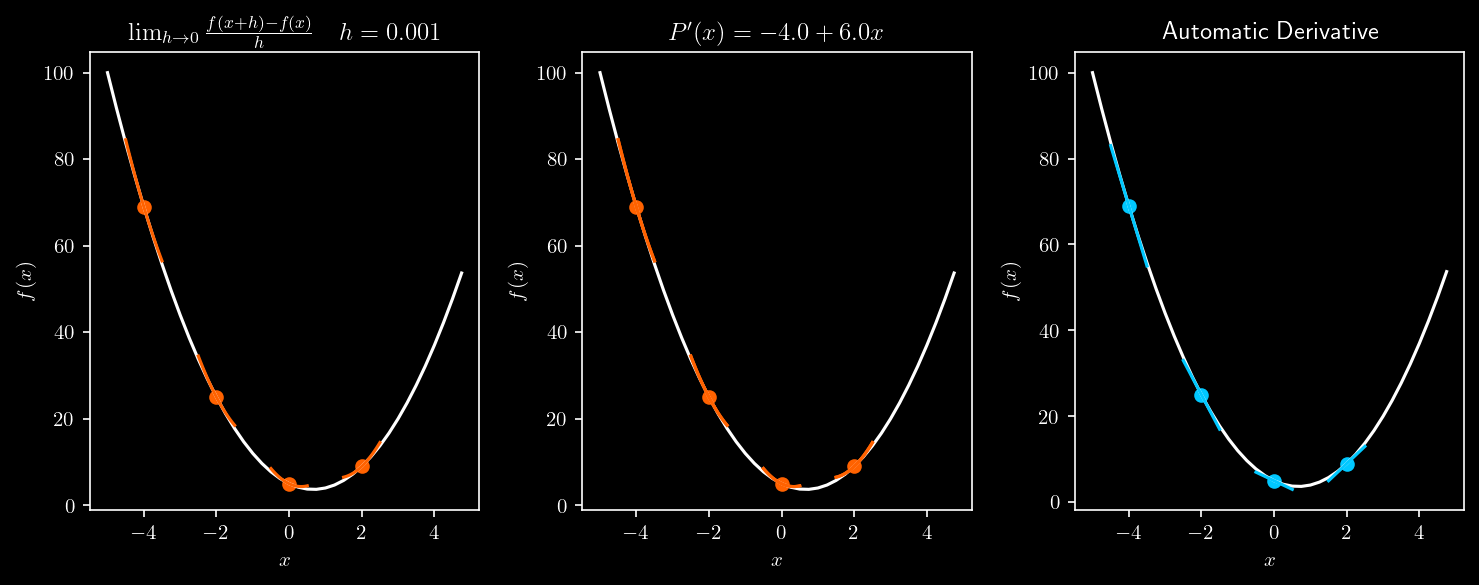

In [175]:
# Continuous numerical derivative: for continuous functions
Polynomial = np.polynomial.Polynomial
f = Polynomial([5,-4,3])
# Automatic derivative Part
f_jax = lambda x: 3*x**2 - 4*x + 5

display(f)
display(f.deriv())

xs = np.arange(-5,5,0.25)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(10,4),dpi=150)
for ax in ax1,ax2,ax3: ax.plot(xs,f(xs),color='#FFFFFF') ; ax.set_xlabel(r'$x$') ; ax.set_ylabel(r'$f(x)$')

#plt.plot(xs,f(xs),color='#FFFFFF')
#plt.xlabel(r'$x$')
#plt.ylabel(r'$f(x)$')

x0 = np.array([-4.0,-2.0,0.0,2.0]) ; y0 = f(x0)
x = np.linspace(x0-0.5,x0+0.5,100)
y_line = deriv_fwd(f,x)*(x - x0) + y0
y_line_pol = f.deriv()(x)*(x-x0)+y0

# Automatic derivative Part
slope0 = vmap(grad(f_jax))(jnp.array(x0))
y_line_jax = slope0 * (x - x0) + y0

#plt.plot(xs,f(xs),color='#FFFFFF') ; plt.xlabel(r'$x$') ; plt.ylabel(r'$f(x)$')
for ax in ax1,ax2: ax.scatter(x0,y0,color='#FF6200') ; ax.plot(x,y_line,color="#FF6200")
ax2.plot(x,y_line_pol,color="#FF6200")
ax1.set_title(r'$\lim_{h \to 0} \frac{f(x+h) - f(x)}{h} \quad h=0.001$')
ax2.set_title(rf"$P'(x)= {f.deriv()}$")

ax3.scatter(np.asarray(x0), np.asarray(y0), color="#00C8FF")
ax3.plot(np.asarray(x), np.asarray(y_line_jax), color="#00C8FF")
ax3.set_title("Automatic Derivative")
plt.tight_layout()

# symbolic 
# Discrete numerical derivative: for discrete Dateset
'''
y_line_np = np.gradient(f(x),x)*(x - x0) + y0
ax2.scatter(x0,y0,color="#00C8FF") ; ax2.plot(x,y_line_np,color="#00C8FF")
ax2.set_title('use np.gradient()')
plt.tight_layout()
'''

In [118]:
from sympy.abc import x, y, z
from sympy import pprint

def dfunc(Vec):
    dV_dx = smp.diff(Vec,x) ; dx = smp.diff(x)
    dV_dy = smp.diff(Vec,y) ; dy = smp.diff(y)
    dV_dz = smp.diff(Vec,z) ; dz = smp.diff(z)
    return dV_dx*dx + dV_dy*dy + dV_dz*dz

v = smp.Matrix([x**2,y**2,0])
display(dfunc(v))
C = CoordSys3D('C')
v = C.x**2 * C.i + C.y**2 * C.j
smp.vector.Del().dot(v).doit()

Matrix([
[2*x],
[2*y],
[  0]])

2*C.x + 2*C.y

<p id='sec6' dir="rtl" style="font-family: Estedad ; font-size: 20px" align="right">انتگرال گیری</p>

In [119]:
# Integral of a Power Function
def pow_int(n,x): return x**(n+1)/(n+1)
# Fundamental Theorem of Calculus
def def_int(f,a,b):
    result, _ = sp.integrate.quad(f,a,b)
    return result

<p id='sec6' dir="rtl" style="font-family: Estedad ; font-size: 20px" align="right"> مشتق سویی </p>

<p id='sec7' dir="rtl" style="font-family: Estedad ; font-size: 20px" align="right"> گرادیان میدان برداری </p>

In [120]:
# def grad(Vec): return [smp.diff(v,x)[0],smp.diff(v,y)[1],smp.diff(v,z)[2]]
#v = np.array([x**2,y**2,0])
#def grad(Vec): return [smp.diff(Vec[0],x),smp.diff(Vec[1],y),smp.diff(Vec[2],z)]
#print(grad(v),(np.array([np.diff(x),np.diff(y),np.diff(z)])))

## Problems

1.1

In [121]:
# A,B,C,D
vec1 = np.array([[1,1,1],[2,3,0],[3,5,-2],[0,-1,1]])
AB = vec1[1]-vec1[0] ; AB_norm = np.linalg.norm(AB)
CD = vec1[3] - vec1[2] ; CD_norm = np.linalg.norm(CD)
print(AB,CD,AB_norm,CD_norm)
print(np.cross(AB,CD))
print(AB_norm/CD_norm)

[ 1  2 -1] [-3 -6  3] 2.449489742783178 7.3484692283495345
[0 0 0]
0.3333333333333333


1.2

In [122]:
vec2 = np.array([[1,4,3],[4,2,-4]])
np.dot(vec2[0],vec2[1])

np.int64(0)

1.3

In [123]:
vec3 = np.array([[2,-1,1],[1,-3,-5],[3,-4,-4]])
# check c^2 = a^2 + b^2
print(np.linalg.norm(vec3[0]),np.linalg.norm(vec3[1]),np.linalg.norm(vec3[2]))
print(np.linalg.norm(vec3[0])**2 + np.linalg.norm(vec3[1])**2 == np.linalg.norm(vec3[2])**2)
# check oto-normal
np.dot(vec3[0],vec3[1])

2.449489742783178 5.916079783099616 6.4031242374328485
True


np.int64(0)

1.4

$$ |A|^2= B^2 - 2BC \cos{\theta} + C^2 $$

In [124]:
Bx ,By ,Bz ,Cx ,Cy ,Cz = smp.symbols('B_x B_y B_z C_x C_y C_z')
B = smp.Matrix([Bx,By,Bz]) ; C = smp.Matrix([Cx,Cy,Cz])
B = Bx*N.i + By*N.j + Bz*N.k ; C = Cx*N.i + Cy*N.j + Cz*N.k
A = B - C
tetha = A.dot(A) - C.dot(C) - B.dot(B) 
print(A.dot(A) == (B.dot(B) - 2*B.dot(C) + C.dot(C)))

False


1.5

## References
- Mathematics of Machine Learning Master linear algebra, Tivadar Danka, 2025, Packt Publisher

- Learning Scientific Programming with Python, Christian Hill, Christian Hill, 2nd Edition, 2020, Cambridge University Press (Virtual Publishing)

- Deep Learning by Ian Goodfellow, Yoshua Bengio, Aaron Courville (z-lib.org)

- Mathematical Methods using Python Applications in Physics and Engineering, (asilis Pagonis ,Christopher W. Kulp)

- Computational Mathematics An introduction to Numerical,  Dimitrios Mitsotakis, Advances in Applied Mathematics, 1,2023 ,Chapman and Hall CRC

- Basics of Linear Algebra for Machine Learning: Discover the Mathematical Language of Data in Python ,Jason Brownlee

- MATHEMATICS FOR MACHINE LEARNING: A Comprehensive Guide to Building Mathematical Foundations for AI and Data Science , Part 1 : Beginner level, Mohamed AAZI